# AG-HYPOPT · Trial 07

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Six trials; the best is now **trial_06** `cvm_fwhm` **0.0764**, just ahead of trial_05 `cvm_fwhm`
**0.0777**, with the KDE control at **0.080328** and the other families clearly behind (`w1_2d` 0.0895,
`w1_fwhm` 0.0908, `energy_2d` 0.0996, `mmd_2d` 0.1833). The `cvm_fwhm` win replicated across two seeds
(sw 0.2345 then 0.2074) and its benefit is entirely in gamma (best gamma RMSE 2.40 / rel 24.2 %), while
mu stays at rel ~33 % for all families. A key open question: both winning trials sat at sw ~0.21-0.23,
and sw is not fully inert even for `cvm_fwhm`, so it is not yet clear whether the gain is the loss
*form* or simply this `sigma_weight` region. Phase `trials` (6/5), EI-guided.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_07'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (6/5 trials)
ID |     ei | params
 1 | 3.9476 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.23081150678768064}
 2 | 1.0309 | {"loss_family": "w1_2d", "sigma_weight": 0.8735534453962619}
 3 | 3.8489 | {"loss_family": "kde", "sigma_weight": 0.2278693029558615}
 4 | 1.1394 | {"loss_family": "mmd_2d", "sigma_weight": 0.2784256121007733}
 5 | 3.6884 | {"loss_family": "energy_2d", "sigma_weight": 0.20704206452386484}
 6 | 3.7084 | {"loss_family": "w1_fwhm", "sigma_weight": 0.2283360048551915}
 7 | 3.6992 | {"loss_family": "w1_fwhm", "sigma_weight": 0.20966133156560723}
 8 | 3.7029 | {"loss_family": "w1_2d", "sigma_weight": 0.21112268319841113}
 9 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.5148888202713703}
10 |      - | {"loss_family": "kde", "sigma_weight": 0.4662060253252891}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI ranks candidate 1 (`cvm_fwhm`, sw 0.2308) highest (ei 3.9476), then candidate 3 (`kde`, sw 0.2279,
ei 3.8489), then 6 (`w1_fwhm`, sw 0.2283). The batch is telling: the proposer wants to probe the
**winning `sigma_weight` region (~0.21-0.23)** across families. There is already a `cvm_fwhm` point
almost exactly at candidate 1's setting (trial_05, sw 0.2345), so re-running it would mostly re-confirm
0.0777; however the *kde* control has never been tested at this low sw (its reference 0.0803 came from
the exp6 setting). That makes candidate 3 the highest-information experiment available: if `kde` at
sw 0.228 also drops toward ~0.077, the `cvm_fwhm` win is really a `sigma_weight` effect and the loss
FORM does not matter; if `kde` stays at ~0.080, the `cvm_fwhm` advantage is genuine. Disentangling those
two is worth more than another confirmatory `cvm_fwhm` run.

I choose candidate 3.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'kde', 'sigma_weight': 0.2278693029558615}
Running  1nW Trans05 ... 

μ 9.39 -> 5.93 | γ 8.5 -> 5.30 | NLL 0.16


Running  1nW Trans20 ... 

μ 17.32 -> 25.65 | γ 8.5 -> 5.28 | NLL 0.44


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 60.99 | γ 14.1 -> 13.90 | NLL 0.57


Running 3nW Trans100 ... 

μ 175.71 -> 98.46 | γ 14.1 -> 13.78 | NLL 0.56



Total: 7.7 min


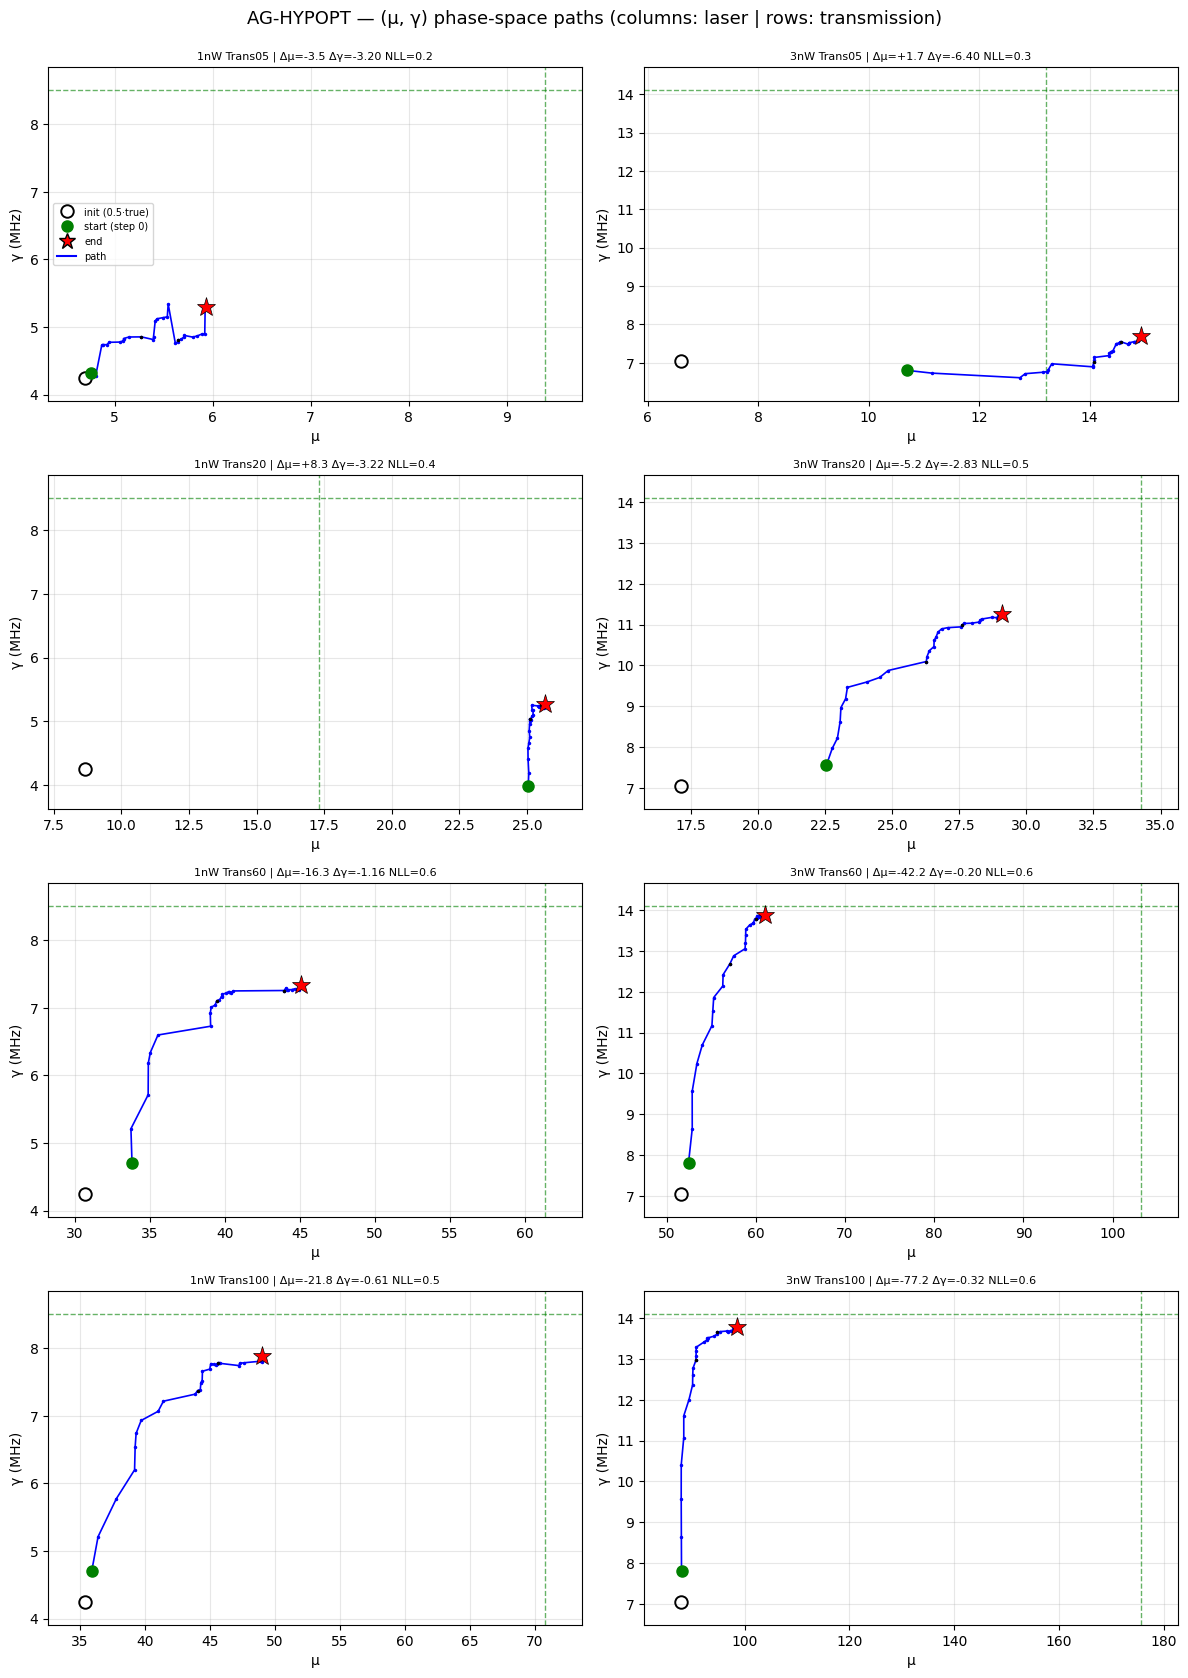

trial finished in 7.7 min
objective = 0.0830 ± 0.0203
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.93   -36.8 |     8.50    5.30   -37.7
1nW Trans20       17.32   25.65   +48.1 |     8.50    5.28   -37.9
1nW Trans60       61.37   45.08   -26.5 |     8.50    7.34   -13.7
1nW Trans100       70.82   49.05   -30.7 |     8.50    7.89    -7.2
3nW Trans05       13.20   14.94   +13.1 |    14.10    7.70   -45.4
3nW Trans20       34.28   29.11   -15.1 |    14.10   11.27   -20.1
3nW Trans60      103.20   60.99   -40.9 |    14.10   13.90    -1.4
3nW Trans100      175.71   98.46   -44.0 |    14.10   13.78    -2.3

weighted objective (T-graded, cap=1.0) = 0.0830 | diverged cells: 0
μ: RMSE 32.785 (rel 34.1%, bias -19.510) | γ: RMSE 2.990 (rel 26.4%, bias -2.244)


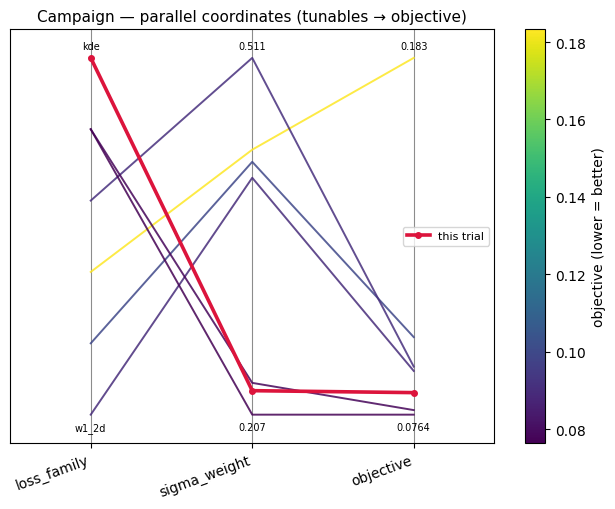

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'kde', sigma_weight: 0.2279}` (candidate 3) - the KDE
control run at the low sw where `cvm_fwhm` won. Trial time 7.7 min, objective **0.0830 +/- 0.0203**,
**0 diverged cells**. That is statistically indistinguishable from the control reference (0.080328)
and clearly *worse* than `cvm_fwhm` (0.0764 / 0.0777).

**What this trial settles.** The proposer's batch was probing the winning `sigma_weight` region
(~0.21-0.23) across families, so the question was whether `cvm_fwhm`'s win is really just 'sw ~0.22 is a
good setting' rather than the loss form. Moving KDE into that same region (sw 0.2279) does **not**
improve it: 0.0830 vs 0.0803, i.e. no better than its own reference. So the `cvm_fwhm` gain is **not** a
sigma_weight artifact - the low-sw region is not magic on its own; the loss form matters.

**Per-cell behaviour.**

- 1nW Trans05: mu -36.8 %, gamma 8.5 -> 5.30 (-37.7 %) - gamma better than the control's usual, mu similar.
- 1nW Trans20: mu +48.1 %, gamma -37.9 %.
- 1nW Trans60 / Trans100: mu -26.5 % / -30.7 %, gamma -13.7 % / -7.2 %.
- 3nW Trans05 / Trans20: mu +13.1 % / -15.1 %, gamma -45.4 % / -20.1 % (3nW Trans05 gamma clearly
  worse than `cvm_fwhm`'s -28.8 %).
- 3nW Trans60 / Trans100: mu -40.9 % / -44.0 %, gamma -1.4 % / -2.3 %.

**Aggregates.** mu: RMSE 32.79 (rel 34.1 %), bias -19.51; gamma: RMSE 2.99 (rel 26.4 %), bias -2.24 -
gamma worse than both `cvm_fwhm` trials (2.40-2.47 / 24.2-24.6 %), mu about the same as always.

**Summary:** The KDE control at sw 0.2279 gives objective 0.0830, no better than its own reference
(0.0803) and clearly behind `cvm_fwhm` (0.0764), showing the low-sw region does not by itself produce the
gain.
**Key insight:** The `cvm_fwhm` advantage is a genuine loss-FORM effect, not a `sigma_weight` region
artifact - KDE moved to the same sw stays at control level.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'The KDE control at sigma_weight 0.2279 gives objective 0.0830, no better than its own reference (0.0803) and clearly behind cvm_fwhm (0.0764), so the low-sw region does not by itself produce the gain.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The cvm_fwhm advantage is a genuine loss-FORM effect, not a sigma_weight-region artifact: KDE moved to the same sw stays at control level.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_07 | current best: trial_06


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_08.ipynb. Open it and follow its cells from the top.
